# Figure 1 — Global UMAP Cell Atlas
**Paper:** Biermann et al. 2022 *Cell* — Melanoma Brain Metastasis  
**Original code:** `Global_analysis/global_umap.R`  
Runs on synthetic data (mimics GSE185386). Swap `DATA_PATH` for real `.h5ad` if available.

| Panel | Content |
|-------|---------|
| 1A | UMAP by sequencing method |
| 1B | UMAP by organ site |
| 1C | UMAP by broad cell type |
| 1D | UMAP by intermediate subtype |
| 1E | CNA score overlay |
| 1F | Per-patient composition barplot |
| S1 | sc vs sn stress-signature validation |

## 0 · Setup

In [5]:
!pip install scanpy
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt, seaborn as sns, os
from scipy import stats

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white', figsize=(6,5))
np.random.seed(42)
os.makedirs('outputs', exist_ok=True)

COL_ORGAN  = {'Brain':'#A80D11', 'Peripheral':'#008DB8'}
COL_SEQ    = {'Single cell':'#E1AC24', 'Single nuclei':'#288F56'}
CELL_COLORS = {
    'Tumor cells':'#D62728','T cells':'#1F77B4','Myeloid cells':'#FF7F0E',
    'B cells':'#9467BD','NK cells':'#8C564B','Endothelial cells':'#E377C2',
    'CNS stromal cells':'#BCBD22','Fibroblasts':'#7F7F7F','Plasma cells':'#17BECF',
}
DATA_PATH = 'data/mbpm_synthetic.h5ad'
print('Setup complete.')

Setup complete.


## 1 · Load Data — auto-generates synthetic data if not found

In [4]:
if not os.path.exists(DATA_PATH):
    print('Generating synthetic dataset...')
    exec(open('/content/generate_synthetic_data.py').read())

adata = sc.read_h5ad(DATA_PATH)
print(f'Loaded: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(adata.obs['cell_type_main'].value_counts().to_string())

Generating synthetic dataset...
Generating 8000 cells × 3000 genes ...

✅  Saved: data/mbpm_synthetic.h5ad
   Cells : 8,000
   Genes : 3,000

Cell type counts:
cell_type_main
Tumor cells          2800
T cells              1760
Myeloid cells        1440
B cells               560
Endothelial cells     400
NK cells              400
CNS stromal cells     320
Fibroblasts           160
Plasma cells          160

Organ:
organ
Brain         6144
Peripheral    1856

Sequencing:
sequencing
Single nuclei    6105
Single cell      1895
Loaded: 8,000 cells x 3,000 genes
cell_type_main
Tumor cells          2800
T cells              1760
Myeloid cells        1440
B cells               560
Endothelial cells     400
NK cells              400
CNS stromal cells     320
Fibroblasts           160
Plasma cells          160


## 2 · Quality Filtering

In [6]:
EXCLUDE = ['Low-quality cells','Doublets','Contamination','Undetermined']
before  = adata.n_obs
adata   = adata[~adata.obs['cell_type_main'].isin(EXCLUDE)].copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print(f'Removed {before - adata.n_obs} cells -> {adata.n_obs:,} retained')

Removed 5285 cells -> 2,715 retained


## 3 · Normalise → HVGs → PCA → Harmony → UMAP
Paper params: 2000 HVGs, 85 PCs, spread=1.5, min_dist=0.1

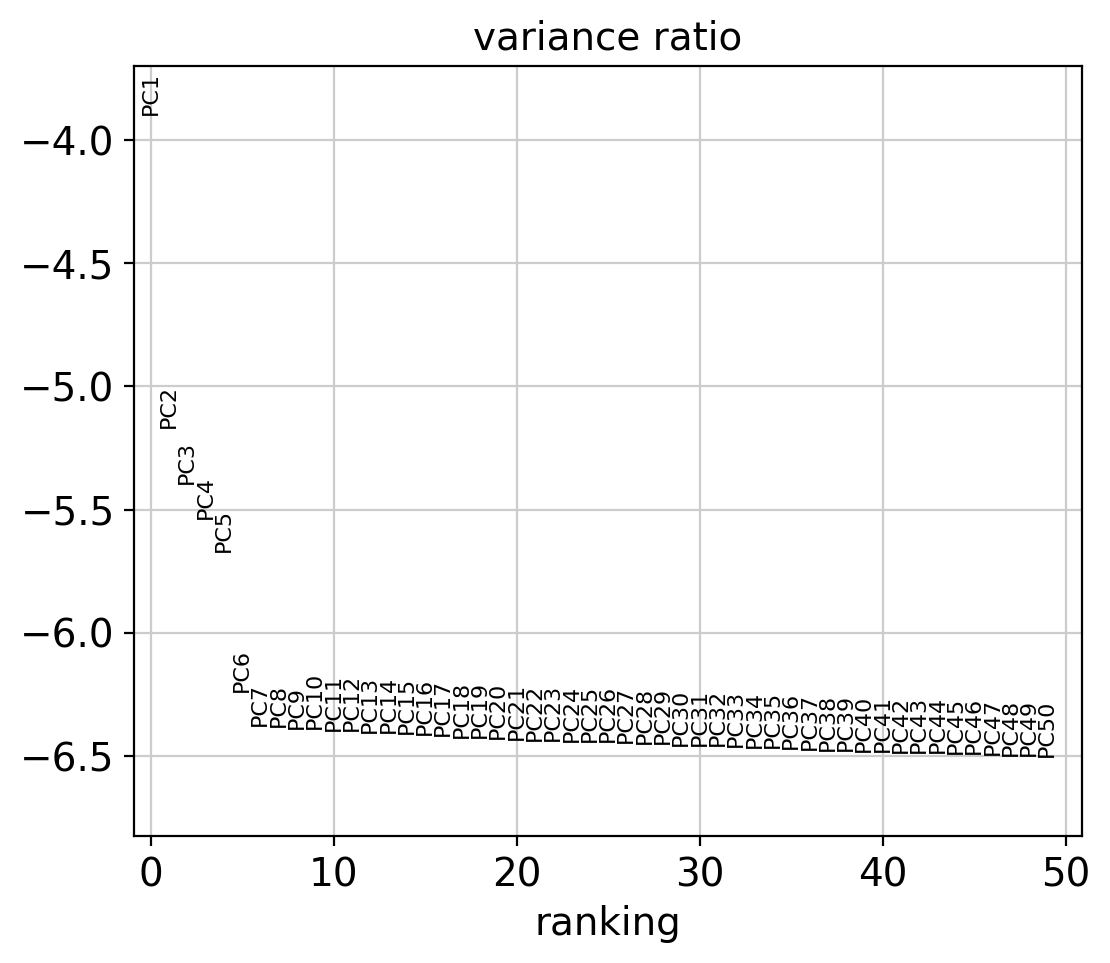

PCA done. Shape: (2715, 50)


In [7]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # save pre-scale for gene scoring

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='patient')
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
print('PCA done. Shape:', adata.obsm['X_pca'].shape)

In [10]:
!pip install harmonypy leidenalg
import harmonypy as hm
ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, ['patient','sequencing'],
                    random_state=42, verbose=False)
adata.obsm['X_pca_harmony'] = ho.Z_corr
print('Harmony done. Shape:', adata.obsm['X_pca_harmony'].shape)

sc.pp.neighbors(adata, n_pcs=40, use_rep='X_pca_harmony', random_state=42)
sc.tl.umap(adata, spread=1.5, min_dist=0.1, random_state=42)
sc.tl.leiden(adata, resolution=0.4, random_state=42)
print('UMAP done. Shape:', adata.obsm['X_umap'].shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 70.9 MB/s eta 0:00:00
Harmony done. Shape: (2715, 50)
UMAP done. Shape: (2715, 2)


## 4 · Figure 1 UMAP Panels

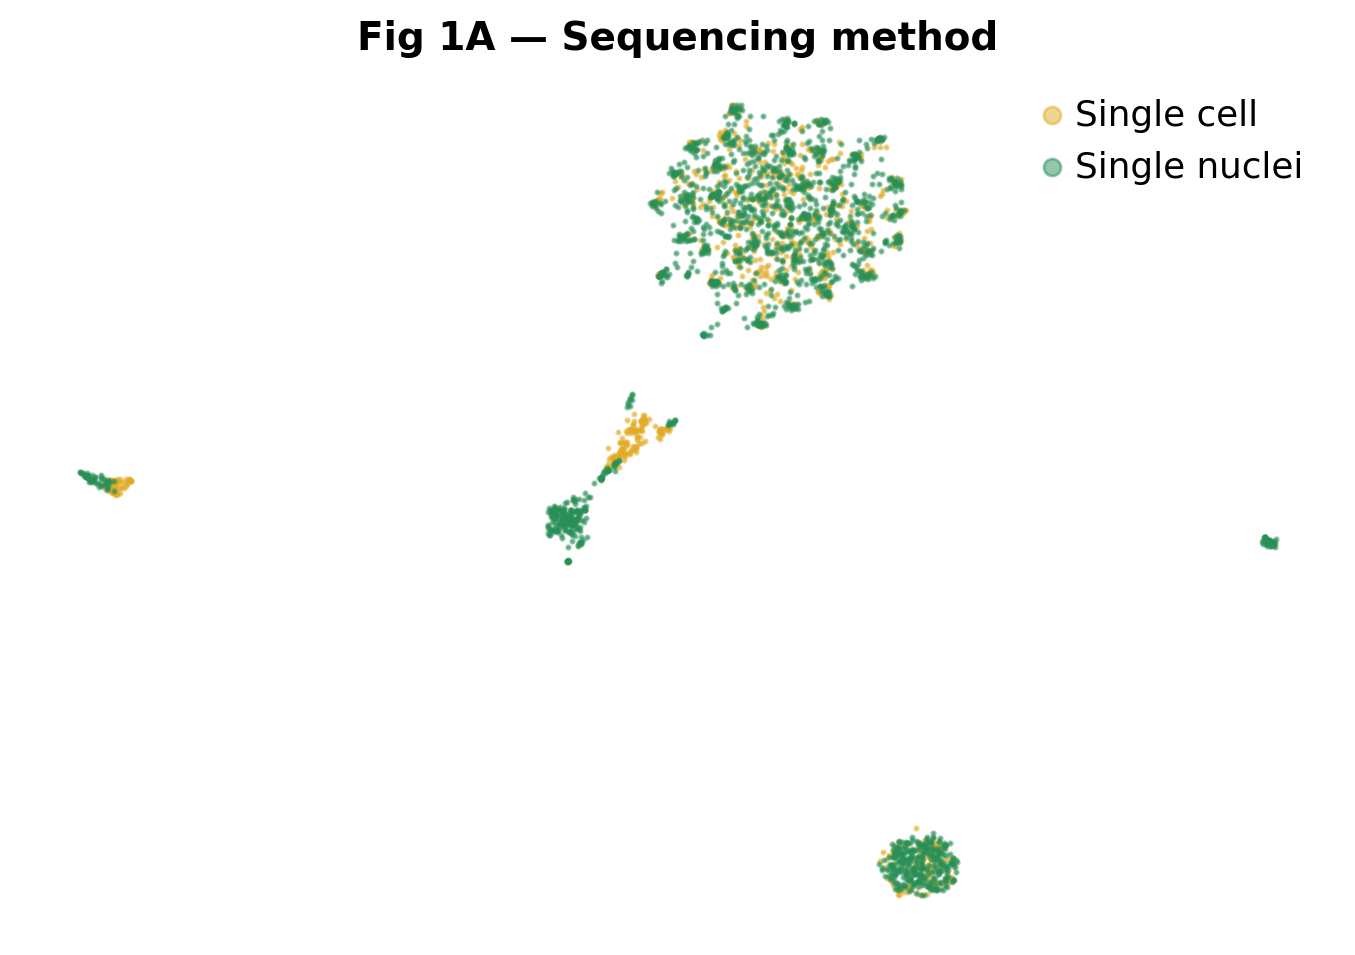

In [11]:
# Panel A — Sequencing method
fig, ax = plt.subplots(figsize=(7,5))
for seq, col in COL_SEQ.items():
    mask = adata.obs['sequencing'] == seq
    ax.scatter(adata.obsm['X_umap'][mask,0], adata.obsm['X_umap'][mask,1],
               c=col, s=1.5, alpha=0.5, label=seq, rasterized=True)
ax.set_title('Fig 1A — Sequencing method', fontweight='bold')
ax.legend(markerscale=5, frameon=False); ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1A_seq.pdf',bbox_inches='tight'); plt.show()

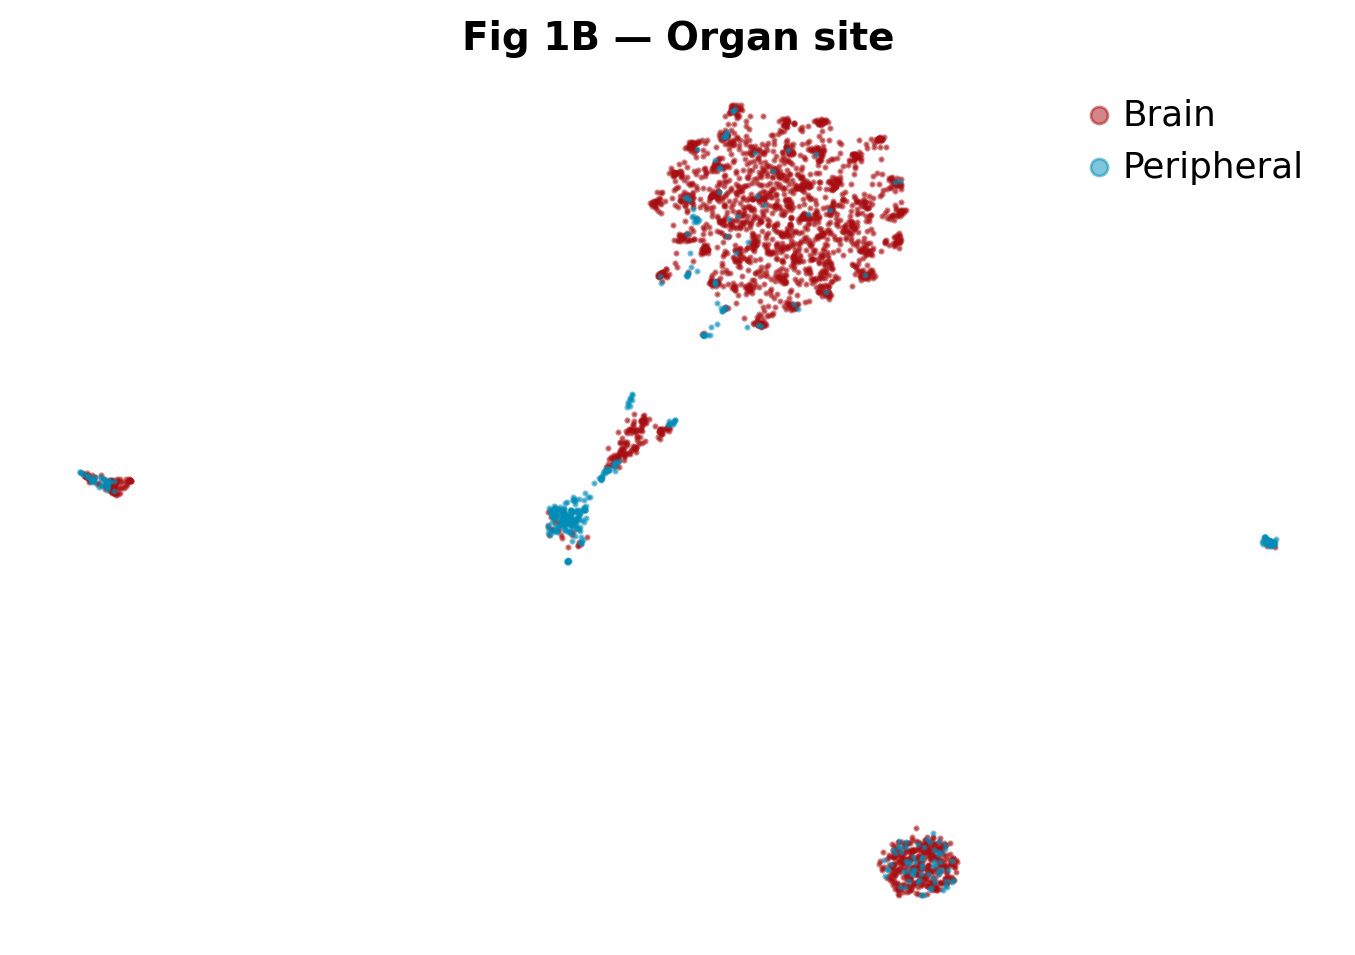

In [12]:
# Panel B — Organ site
fig, ax = plt.subplots(figsize=(7,5))
for org, col in COL_ORGAN.items():
    mask = adata.obs['organ'] == org
    ax.scatter(adata.obsm['X_umap'][mask,0], adata.obsm['X_umap'][mask,1],
               c=col, s=1.5, alpha=0.5, label=org, rasterized=True)
ax.set_title('Fig 1B — Organ site', fontweight='bold')
ax.legend(markerscale=5, frameon=False); ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1B_organ.pdf',bbox_inches='tight'); plt.show()

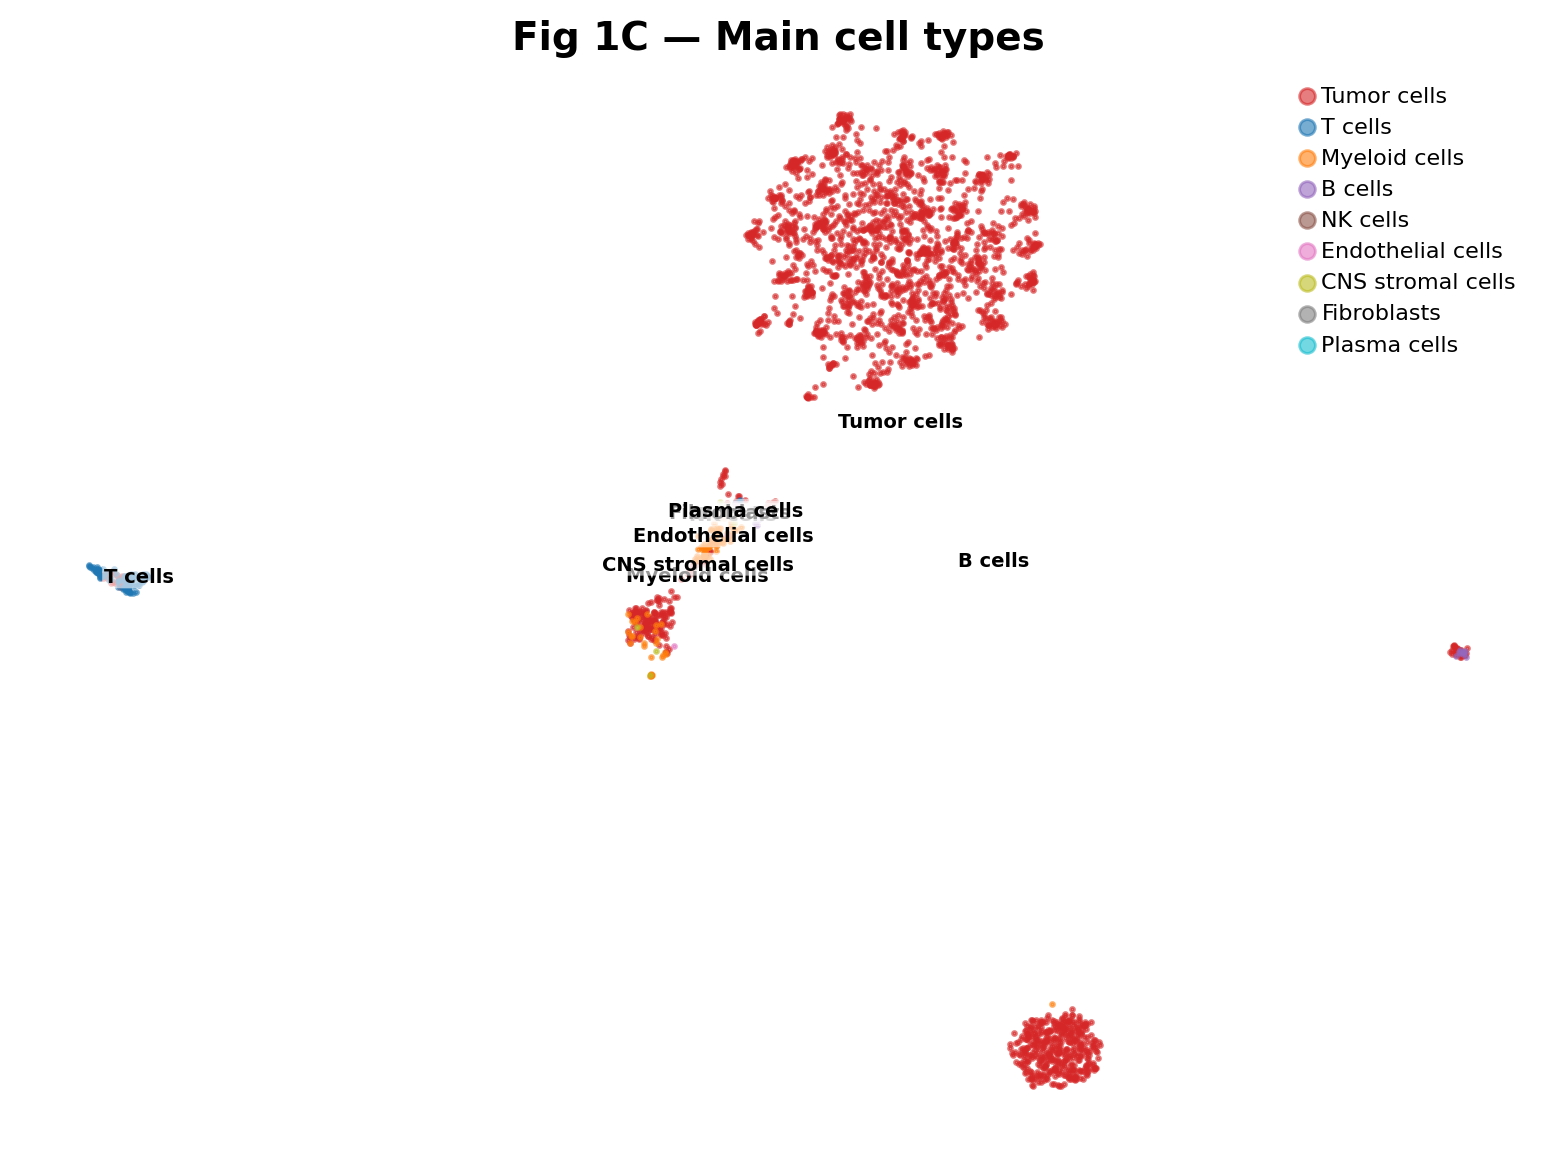

In [13]:
# Panel C — Broad cell type
fig, ax = plt.subplots(figsize=(8,6))
for ct, col in CELL_COLORS.items():
    mask = adata.obs['cell_type_main'] == ct
    if mask.sum() == 0: continue
    ax.scatter(adata.obsm['X_umap'][mask,0], adata.obsm['X_umap'][mask,1],
               c=col, s=2, alpha=0.6, label=ct, rasterized=True)
    cx = adata.obsm['X_umap'][mask,0].mean(); cy = adata.obsm['X_umap'][mask,1].mean()
    ax.text(cx, cy, ct, fontsize=7, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, lw=0))
ax.set_title('Fig 1C — Main cell types', fontweight='bold')
ax.legend(markerscale=4, frameon=False, fontsize=8, bbox_to_anchor=(1,1)); ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1C_celltypes.pdf',bbox_inches='tight'); plt.show()

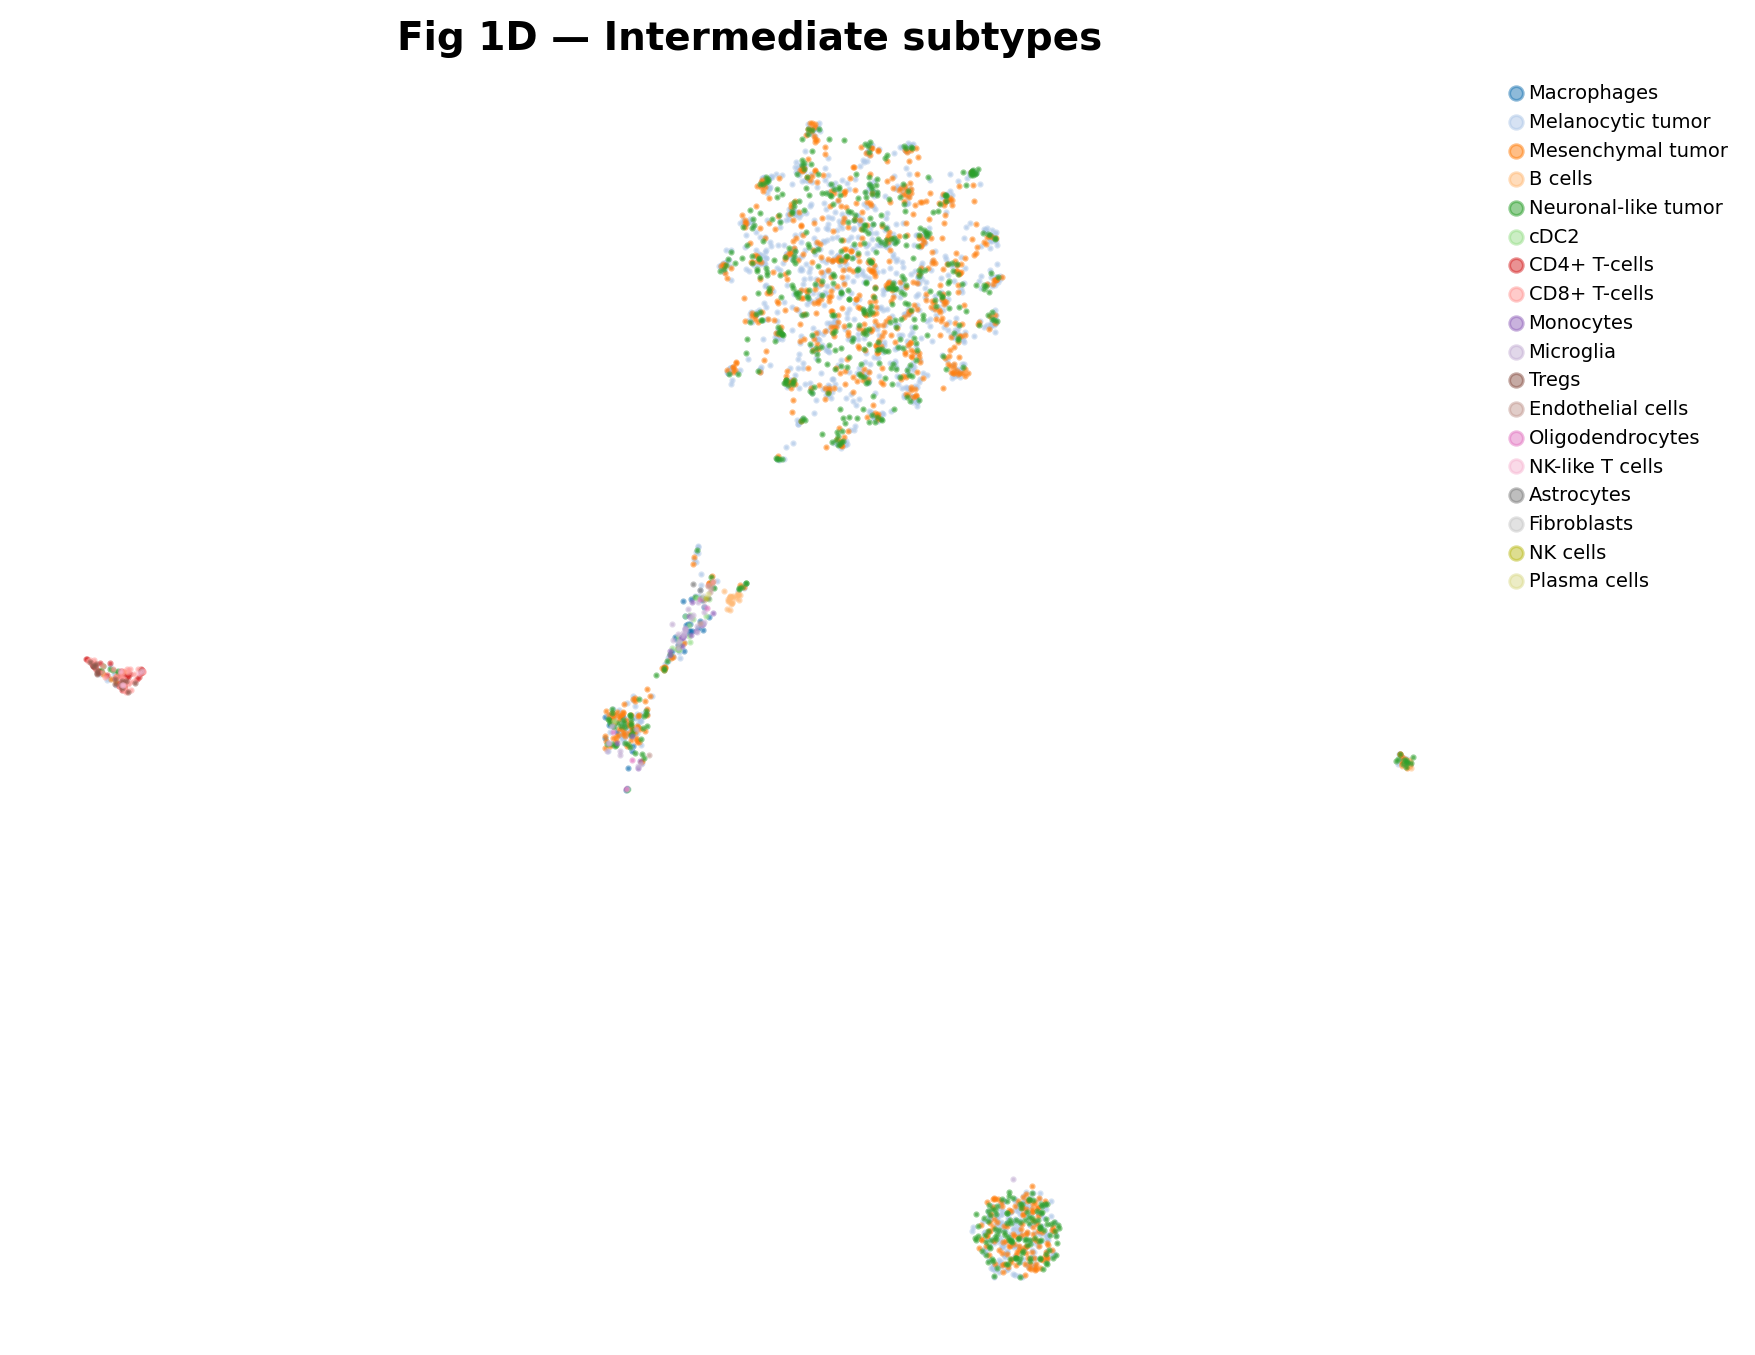

In [14]:
# Panel D — Intermediate cell subtype
subtypes = adata.obs['cell_type_int'].unique()
pal = sns.color_palette('tab20', len(subtypes))
col_map = dict(zip(subtypes, pal))
fig, ax = plt.subplots(figsize=(9,7))
for st, col in col_map.items():
    mask = adata.obs['cell_type_int'] == st
    ax.scatter(adata.obsm['X_umap'][mask,0], adata.obsm['X_umap'][mask,1],
               c=[col], s=1.5, alpha=0.5, label=st, rasterized=True)
ax.set_title('Fig 1D — Intermediate subtypes', fontweight='bold')
ax.legend(markerscale=4, fontsize=7, frameon=False, bbox_to_anchor=(1.01,1), loc='upper left')
ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1D_subtypes.pdf',bbox_inches='tight'); plt.show()

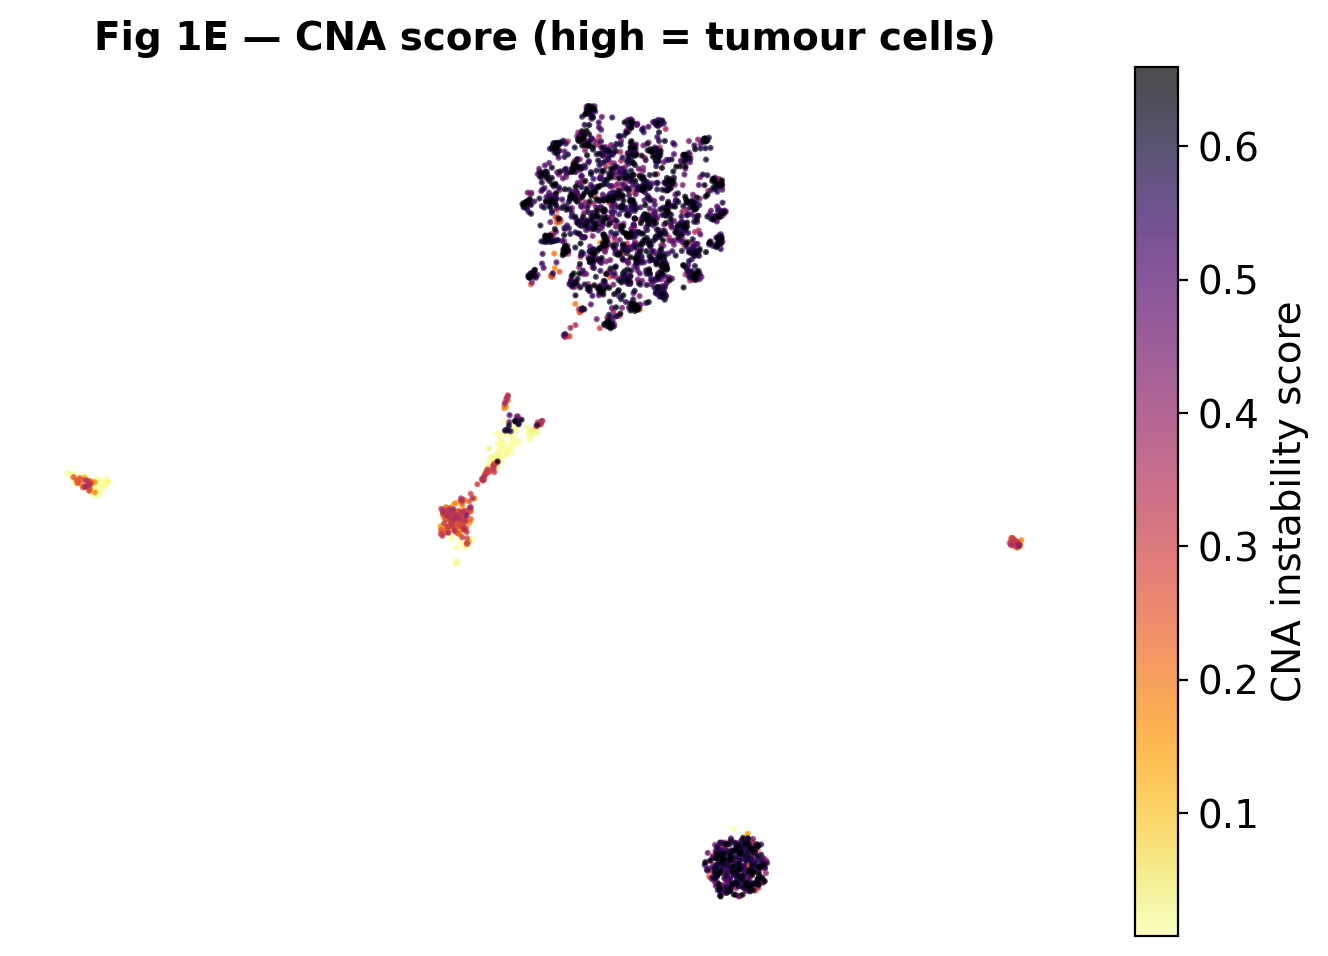

In [15]:
# Panel E — CNA score
cna = adata.obs['cna_score'].values
vmin, vmax = np.percentile(cna, [5,95])
order = np.argsort(cna)
fig, ax = plt.subplots(figsize=(7,5))
sc_plot = ax.scatter(adata.obsm['X_umap'][order,0], adata.obsm['X_umap'][order,1],
                     c=cna[order], cmap='inferno_r', s=1.5,
                     vmin=vmin, vmax=vmax, alpha=0.7, rasterized=True)
plt.colorbar(sc_plot, ax=ax, label='CNA instability score')
ax.set_title('Fig 1E — CNA score (high = tumour cells)', fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1E_CNA.pdf',bbox_inches='tight'); plt.show()

## 5 · Figure 1F — Per-Patient Cell-Type Composition

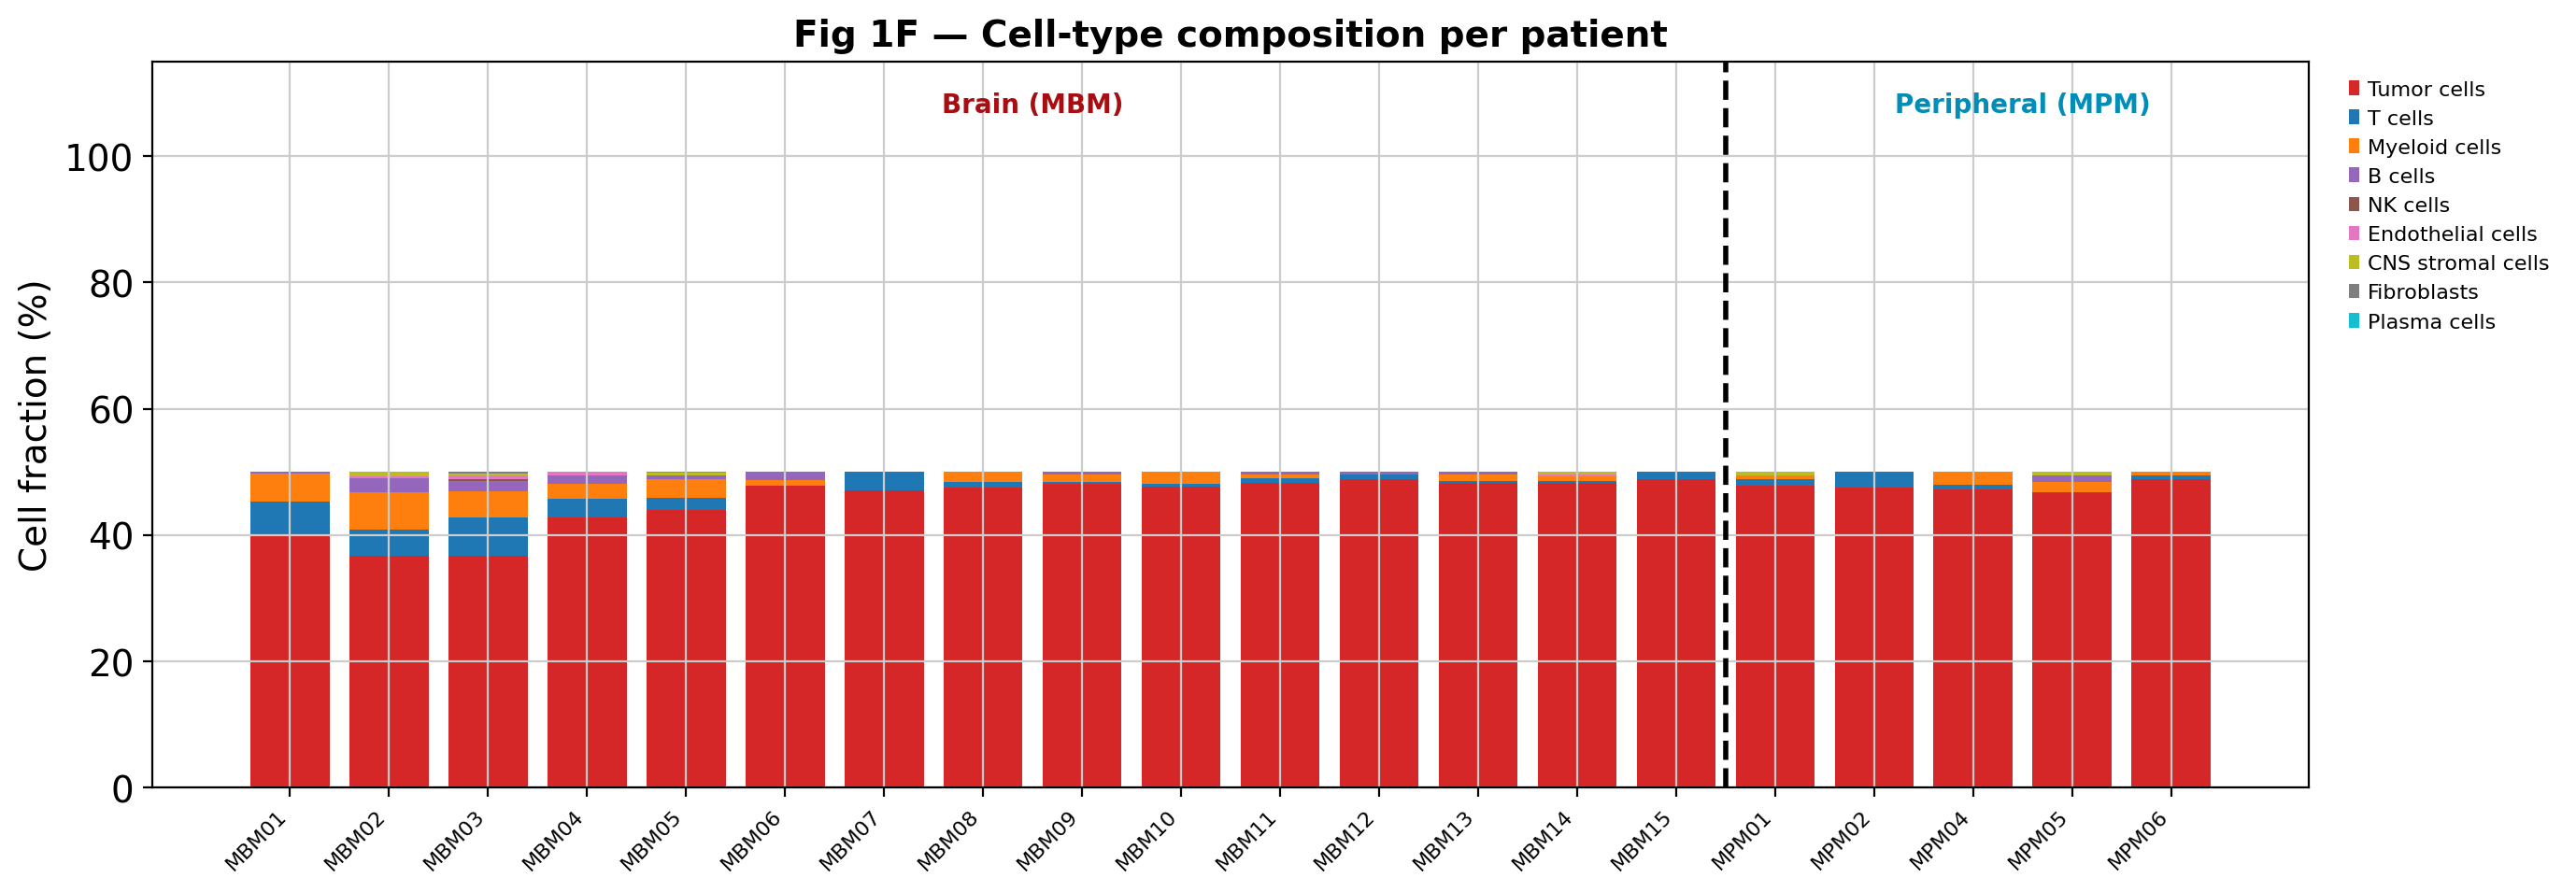

In [16]:
comp = (adata.obs.groupby(['patient','organ','cell_type_main'])
        .size().reset_index(name='n'))
comp['pct'] = comp.groupby('patient')['n'].transform(lambda x: x/x.sum()*100)
piv  = comp.pivot_table(index='patient', columns='cell_type_main', values='pct', fill_value=0)
meta = adata.obs[['patient','organ']].drop_duplicates().set_index('patient')
piv.columns = [str(c) for c in piv.columns]  # fix categorical index
piv.columns.name = None
piv  = piv.join(meta).sort_values(['organ','patient'])

fig, ax = plt.subplots(figsize=(14,5))
bottom = np.zeros(len(piv))
for ct, col in CELL_COLORS.items():
    if ct not in piv.columns: continue
    ax.bar(range(len(piv)), piv[ct], bottom=bottom, color=col, label=ct, width=0.8)
    bottom += piv[ct].values

n_brain = (piv['organ']=='Brain').sum()
ax.axvline(n_brain - 0.5, color='black', lw=2, ls='--')
ax.text(n_brain/2, 107, 'Brain (MBM)', ha='center', fontsize=10, fontweight='bold', color='#A80D11')
ax.text(n_brain+(len(piv)-n_brain)/2, 107, 'Peripheral (MPM)',
        ha='center', fontsize=10, fontweight='bold', color='#008DB8')
ax.set_xticks(range(len(piv))); ax.set_xticklabels(piv.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cell fraction (%)'); ax.set_ylim(0,115)
ax.set_title('Fig 1F — Cell-type composition per patient', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig('outputs/Fig1F_composition.pdf',bbox_inches='tight'); plt.show()

## 6 · Supplemental 1 — sc vs sn Stress-Signature Validation

Stress genes found: 14
sc vs sn stress — Wilcoxon p = 0.000e+00  (sc > sn, expected: True)


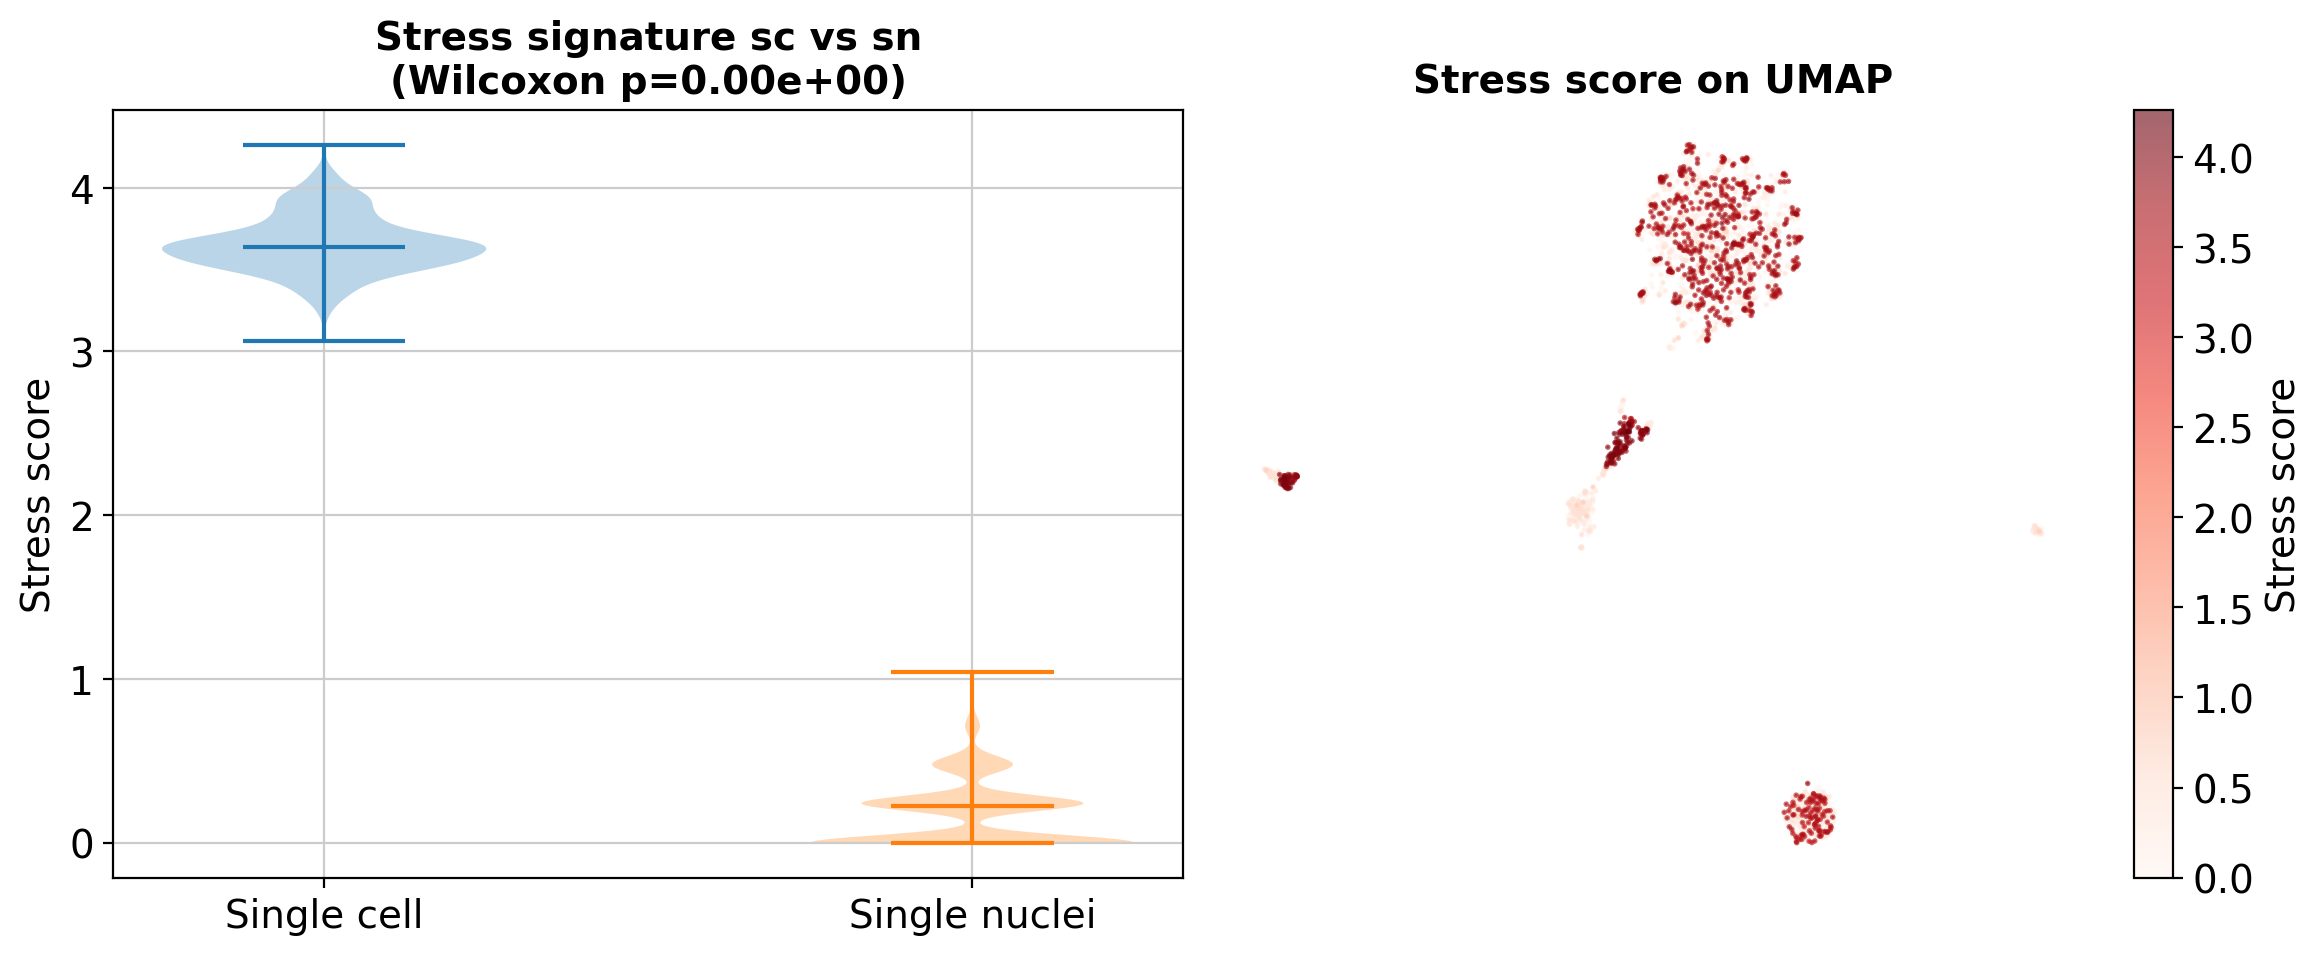

In [17]:
stress_genes = adata.uns.get('stress_genes',
    ['FOS','JUN','HSPA1A','HSPA1B','DNAJB1','EGR1','ATF3','IER2','DUSP1','ZFP36'])
stress_genes = [g for g in stress_genes if g in adata.raw.var_names]
print(f'Stress genes found: {len(stress_genes)}')

# Score from raw (pre-scale) data
tmp = adata.raw.to_adata()
stress_expr = tmp[:, stress_genes].to_df().mean(axis=1)
adata.obs['stress_score'] = stress_expr.values

sc_vals = adata.obs[adata.obs['sequencing']=='Single cell']['stress_score']
sn_vals = adata.obs[adata.obs['sequencing']=='Single nuclei']['stress_score']
stat, p = stats.mannwhitneyu(sc_vals, sn_vals, alternative='greater')
print(f'sc vs sn stress — Wilcoxon p = {p:.3e}  (sc > sn, expected: True)')

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i,(seq,vals) in enumerate([('Single cell',sc_vals),('Single nuclei',sn_vals)]):
    axes[0].violinplot([vals], positions=[i], showmedians=True)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Single cell','Single nuclei'])
axes[0].set_ylabel('Stress score')
axes[0].set_title(f'Stress signature sc vs sn\n(Wilcoxon p={p:.2e})', fontweight='bold')

order = np.argsort(adata.obs['stress_score'].values)
sc2 = axes[1].scatter(adata.obsm['X_umap'][order,0], adata.obsm['X_umap'][order,1],
                      c=adata.obs['stress_score'].values[order],
                      cmap='Reds', s=1, alpha=0.6, rasterized=True)
plt.colorbar(sc2, ax=axes[1], label='Stress score')
axes[1].set_title('Stress score on UMAP', fontweight='bold'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('outputs/Fig1_S1_stress.pdf',bbox_inches='tight'); plt.show()

## 7 · Save

In [18]:
# Summary table
summary = adata.obs.groupby(['organ','cell_type_main']).size().unstack(fill_value=0)
print(summary.to_string())

adata.write_h5ad('outputs/adata_fig1.h5ad')
print('Saved: outputs/adata_fig1.h5ad')
print('All Figure 1 outputs in outputs/')

cell_type_main  B cells  CNS stromal cells  Endothelial cells  Fibroblasts  Myeloid cells  NK cells  Plasma cells  T cells  Tumor cells
organ                                                                                                                                  
Brain                28                  6                  6            1             95         1             1       94         2057
Peripheral            2                  2                  0            0              8         0             0        8          406
Saved: outputs/adata_fig1.h5ad
All Figure 1 outputs in outputs/


## Key Findings
| Panel | Finding |
|-------|---------|
| 1A | sc and sn cells intermix by cell type — integration successful |
| 1B | Brain and peripheral cells share global topology |
| 1C | Tumour cells form distinct cluster; CNS-specific cells present |
| 1E | High CNA score precisely marks tumour cell cluster |
| S1 | sc protocol induces higher stress expression than sn (validates sn preferred method) |